# Proyek Praktikum Penambangan Data (UTS)
### Segmentasi Perilaku dan Profil Risiko Penjudi Daring pada Platform Crash Game Menggunakan Algoritma K-Means Clustering

**Identitas Kelompok 4:**
1. MUHAMMAD RAKAN HIBRIZI
2. JANUARSYAH AKBAR
3. Devin Sotya Prathama
4. SHINOSUKE ALEXANDER SWANDJAYA

**Mata Kuliah:** Praktikum Penambangan Data (SVPL261503)  
**Program Studi:** Sarjana Terapan (D.4) Teknologi Rekayasa Perangkat Lunak  
**Dosen Pengampu:** Dr.Eng. Ir. Ganjar Alfian, S.T., M.Eng. & Dr. Imam Fahrurrozi, S.T., M.Cs.  
**Paper Acuan:** *AI Personalization and Its Influence on Online Gamblers' Behavior* (MDPI Behavioral Sciences, 2025)  
**Dataset:** *Gambling Behavior Bustabit* (Kaggle, 50.000 transaksi)  

---

## 1. Import Library & Pengaturan Lingkungan
Mengimpor pustaka analisis data, visualisasi, dan algoritma machine learning scikit-learn.

In [56]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 110
print('Semua library berhasil dimuat!')

Semua library berhasil dimuat!


## 2. Pemuatan Data (Data Loading)
Memuat dataset `bustabit.csv` langsung dari repositori GitHub Raw. Notebook ini dapat langsung dijalankan di Google Colab tanpa perlu mengunggah file secara manual. Jika dijalankan tanpa koneksi internet, sistem secara otomatis beralih mencari file lokal.

In [57]:
# Tautan dataset langsung dari GitHub Raw
github_raw_url = "https://raw.githubusercontent.com/januarsyah901/PPD/main/UTS/bustabit.csv"

local_candidates = [
    "bustabit.csv",
    "UTS/bustabit.csv",
    "/content/bustabit.csv",
    "../bustabit.csv"
]

try:
    print(f"Memuat dataset dari GitHub Raw: {github_raw_url}")
    df = pd.read_csv(github_raw_url)
    print("Dataset berhasil dimuat langsung dari GitHub Raw!")
except Exception as err:
    print(f"Gagal memuat dari GitHub ({err}), mencoba membaca dari direktori lokal...")
    local_path = next((p for p in local_candidates if os.path.exists(p)), None)
    if local_path is None:
        raise FileNotFoundError("Dataset tidak ditemukan baik di GitHub maupun penyimpanan lokal!")
    df = pd.read_csv(local_path)
    print(f"Dataset berhasil dimuat dari lokal: {local_path}")

print(f"Dimensi data: {df.shape[0]:,} baris dan {df.shape[1]} kolom")
df.head()

Memuat dataset dari GitHub Raw: https://raw.githubusercontent.com/januarsyah901/PPD/main/UTS/bustabit.csv
Dataset berhasil dimuat langsung dari GitHub Raw!
Dimensi data: 50,000 baris dan 9 kolom


,Id,GameID,Username,Bet,CashedOut,Bonus,Profit,BustedAt,PlayDate
0,14196549,3366002,papai,5,1.20,0.0,1.00,8.24,2016-11-20T19:44:19Z
1,10676217,3343882,znay22,3,NaN,NaN,NaN,1.40,2016-11-14T14:21:50Z
2,15577107,3374646,rrrrrrrr,4,1.33,3.0,1.44,3.15,2016-11-23T06:39:15Z
3,25732127,3429241,sanya1206,10,NaN,NaN,NaN,1.63,2016-12-08T18:13:55Z
4,17995432,3389174,ADM,50,1.50,1.4,25.70,2.29,2016-11-27T08:14:48Z


## 3. Data Understanding & Exploratory Data Analysis (EDA)
Menganalisis tipe data, struktur kolom, dan menangani nilai kosong (*missing values*).

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         50000 non-null  int64  
 1   GameID     50000 non-null  int64  
 2   Username   50000 non-null  object 
 3   Bet        50000 non-null  int64  
 4   CashedOut  28734 non-null  float64
 5   Bonus      28734 non-null  float64
 6   Profit     28734 non-null  float64
 7   BustedAt   50000 non-null  float64
 8   PlayDate   50000 non-null  object 
dtypes: float64(4), int64(3), object(2)
memory usage: 3.4+ MB


In [59]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_table = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
})
print('Tabel Missing Values:')
missing_table[missing_table['Jumlah Missing'] > 0]

Tabel Missing Values:


,Jumlah Missing,Persentase (%)
CashedOut,21266,42.53
Bonus,21266,42.53
Profit,21266,42.53


> **Insight Terkait Missing Values:**  
> Kolom `CashedOut`, `Bonus`, dan `Profit` memiliki missing value sebesar ~42.53%. Berdasarkan mekanika permainan crash game Bustabit, nilai kosong ini muncul saat pemain mengalami *bust* (multiplier permainan meledak sebelum pemain mencairkan uang). Jadi ketiadaan data ini merepresentasikan kekalahan taruhan secara sah, bukan data hilang akibat kesalahan input.

In [60]:
df[['Bet', 'CashedOut', 'Bonus', 'Profit', 'BustedAt']].describe().round(2)

,Bet,CashedOut,Bonus,Profit,BustedAt
count,50000.00,28734.00,28734.00,28734.00,50000.00
mean,2935.25,1.69,1.38,1534.77,16.79
std,30651.93,2.19,1.63,20000.82,1172.88
min,1.00,1.00,0.00,0.00,0.00
25%,4.00,1.07,0.00,0.85,1.31
50%,20.00,1.21,1.00,5.33,1.95
75%,180.00,1.57,2.47,63.03,3.85
max,1000000.00,126.00,12.14,1175993.10,251025.13


## 4. Data Preprocessing pada Tingkat Transaksi
Membuat label kemenangan taruhan (`is_win`) dan menghitung keuntungan riil (`actual_profit`). Saat pemain kalah (*bust*), kerugian riil pemain bernilai negatif sebesar taruhan yang dipasang (`-Bet`).

In [61]:
# Menandai apakah taruhan berhasil dicairkan (menang)
df['is_win'] = df['CashedOut'].notna().astype(int)

# Mengisi profit riil: jika kalah, profit bernilai -Bet
df['actual_profit'] = df['Profit'].fillna(-df['Bet'])

print('Distribusi Hasil Taruhan (Tingkat Transaksi):')
print(df['is_win'].value_counts(normalize=True).rename({1: 'Menang (Cashout)', 0: 'Kalah (Bust)'}) * 100)

Distribusi Hasil Taruhan (Tingkat Transaksi):
is_win
Menang (Cashout)    57.468
Kalah (Bust)        42.532
Name: proportion, dtype: float64


## 5. Feature Engineering: User Profiling (Agregasi per Username)
Karena sasaran analisis adalah segmentasi **perilaku individu penjudi**, data transaksi per ronde diagregasi berdasarkan entitas `Username` untuk mendapatkan metrik profil perilaku:
- `total_bets`: Total partisipasi / frekuensi taruhan pemain.
- `avg_bet`: Rata-rata besaran nominal taruhan yang dipertaruhkan (*stake size*).
- `max_bet`: Taruhan tertinggi yang pernah dipasang pemain.
- `win_rate`: Rasio kemenangan taruhan (total menang dibagi total taruhan).
- `avg_cashout`: Rata-rata target multiplier pencairan saat berhasil menang (ukuran toleransi risiko).
- `total_profit`: Total akumulasi keuntungan/kerugian bersih pemain (dalam satuan Bits).
- `avg_profit`: Rata-rata profit atau kerugian per ronde.

In [62]:
user_df = df.groupby('Username').agg(
    total_bets=('Bet', 'count'),
    avg_bet=('Bet', 'mean'),
    max_bet=('Bet', 'max'),
    win_rate=('is_win', 'mean'),
    avg_cashout=('CashedOut', 'mean'),
    total_profit=('actual_profit', 'sum'),
    avg_profit=('actual_profit', 'mean')
).reset_index()

# Bagi pemain yang belum pernah menang, avg_cashout bernilai NaN, kita isi baseline 1.0 (titik impas)
user_df['avg_cashout'] = user_df['avg_cashout'].fillna(1.0)

print(f'Total pemain unik yang berhasil dibuat profilnya: {user_df.shape[0]:,}')
user_df.head()

Total pemain unik yang berhasil dibuat profilnya: 4,149


,Username,total_bets,avg_bet,max_bet,win_rate,avg_cashout,total_profit,avg_profit
0,----------------,3,10.333333,12,0.666667,1.010000,-7.30,-2.433333
1,--dilib--,8,210.750000,757,0.250000,2.070000,-867.63,-108.453750
2,-31337-,4,32.500000,55,0.750000,1.266667,-33.50,-8.375000
3,-Nothing-,65,322.876923,3000,0.646154,1.422857,-3120.69,-48.010615
4,-Tachyon,5,1024.800000,2124,0.800000,1.222500,-1494.32,-298.864000


In [63]:
user_df.describe().round(2)

,total_bets,avg_bet,max_bet,win_rate,avg_cashout,total_profit,avg_profit
count,4149.00,4149.00,4149.00,4149.00,4149.00,4149.00,4149.00
mean,12.05,4845.24,12677.78,0.58,1.88,551.25,-220.56
std,24.82,27329.34,66222.74,0.37,2.79,81109.33,23622.17
min,1.00,1.00,1.00,0.00,1.00,-1465227.51,-622500.00
25%,1.00,21.00,52.00,0.27,1.05,-200.00,-42.91
50%,3.00,170.00,500.00,0.62,1.25,1.50,0.53
75%,10.00,1064.02,3000.00,1.00,1.82,249.24,55.68
max,291.00,688000.00,1000000.00,1.00,98.00,3182621.34,937779.70


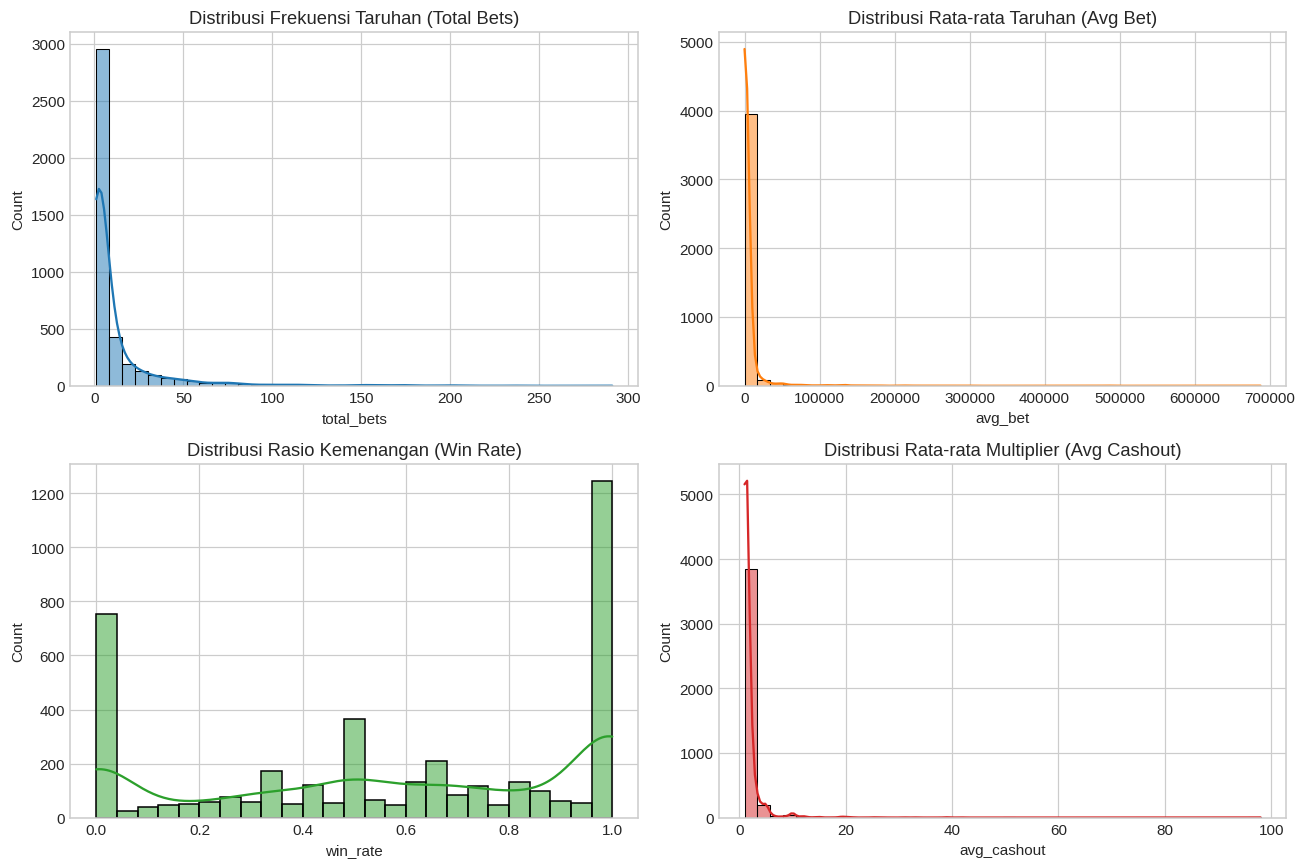

In [64]:
# Visualisasi distribusi metrik perilaku pemain
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(user_df['total_bets'], bins=40, kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Distribusi Frekuensi Taruhan (Total Bets)')

sns.histplot(user_df['avg_bet'], bins=40, kde=True, ax=axes[0, 1], color='#ff7f0e')
axes[0, 1].set_title('Distribusi Rata-rata Taruhan (Avg Bet)')

sns.histplot(user_df['win_rate'], bins=25, kde=True, ax=axes[1, 0], color='#2ca02c')
axes[1, 0].set_title('Distribusi Rasio Kemenangan (Win Rate)')

sns.histplot(user_df['avg_cashout'], bins=40, kde=True, ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Distribusi Rata-rata Multiplier (Avg Cashout)')

plt.tight_layout()
plt.show()

## 6. Audit Kualitas Data Profil: Pemain dengan Observasi Sangat Sedikit
Metrik perilaku seperti `win_rate`, `avg_cashout`, dan `total_profit` tidak stabil bila dihitung dari 1-2 taruhan (contoh: 2 taruhan, 2 menang → `win_rate = 1.00`). Sebelum clustering, distribusi `total_bets` diperiksa dan dibuktikan bahwa clustering pada seluruh pemain menghasilkan klaster yang dibedakan oleh jumlah observasi, bukan oleh pola perilaku.

In [65]:
# Fitur klaster: murni perilaku (profit TIDAK dipakai sebagai fitur)
feature_cols = ['total_bets', 'avg_bet', 'win_rate', 'avg_cashout']

print(user_df['total_bets'].describe().round(2))
print('\nPemain dengan <=2 taruhan: %.1f%%' % ((user_df.total_bets <= 2).mean()*100))

# Baseline (analisis awal): K-Means pada SELURUH pemain, hanya untuk diagnosis
Xb = user_df[feature_cols].copy()
for col in ['total_bets', 'avg_bet', 'avg_cashout']:
    Xb[col] = np.log1p(Xb[col])
Xb_s = StandardScaler().fit_transform(Xb)
base_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(Xb_s)
base = user_df.assign(base_cluster=base_labels).groupby('base_cluster').agg(
    n=('Username', 'count'), median_total_bets=('total_bets', 'median'),
    median_win_rate=('win_rate', 'median'))
print('\nBaseline k=4 pada seluruh pemain:')
print(base)

count    4149.00
mean       12.05
std        24.82
min         1.00
25%         1.00
50%         3.00
75%        10.00
max       291.00
Name: total_bets, dtype: float64

Pemain dengan <=2 taruhan: 43.9%

Baseline k=4 pada seluruh pemain:
                 n  median_total_bets  median_win_rate
base_cluster                                          
0             1067               20.0         0.636364
1             1732                2.0         1.000000
2              354               11.0         0.253571
3              996                2.0         0.000000


> **Temuan audit:** pada baseline, sebagian klaster didominasi pemain bermedian ~1-3 taruhan sehingga label seperti "selalu menang"/"selalu kalah" tidak punya dasar perilaku yang kuat. Baseline ini **tidak** dipakai sebagai hasil akhir.

## 7. Filtering, Transformasi & Penskalaan
Analisis akhir dibatasi pada pemain dengan **minimal 10 taruhan** (`min_bets = 10`). Ketahanan terhadap pilihan threshold diuji pada Bagian 11. Scaler di-*fit* ulang pada data terfilter. Fitur klaster murni perilaku (`total_bets`, `avg_bet`, `win_rate`, `avg_cashout`); `total_profit` **tidak** menjadi fitur dan hanya dipakai sebagai outcome pembanding setelah clustering.

In [66]:
min_bets = 10
d = user_df[user_df.total_bets >= min_bets].copy().reset_index(drop=True)
coverage = len(d) / len(user_df)
print(f'Pemain tersisa: {len(d):,} dari {len(user_df):,} ({coverage:.1%})')

def prepare(frame):
    X = frame[feature_cols].copy()
    for col in ['total_bets', 'avg_bet', 'avg_cashout']:
        X[col] = np.log1p(X[col])
    sc = StandardScaler()
    return sc.fit_transform(X), sc

Xs, scaler = prepare(d)
print('Fitur klaster:', feature_cols)

Pemain tersisa: 1,111 dari 4,149 (26.8%)
Fitur klaster: ['total_bets', 'avg_bet', 'win_rate', 'avg_cashout']


### Hubungan dengan Paper Acuan
Paper acuan memakai data Bustabit dan metode inferensial (uji t, regresi OLS/logistik, panel regression) untuk menguji hipotesis tentang perilaku taruhan. Notebook ini bersifat **pelengkap**, bukan replikasi: (1) dataset yang dipakai sama dengan dataset pertama paper (kingabzpro, 2023): 50.000 taruhan pada platform Bustabit, 31 Oktober sampai 10 Desember 2016. Dataset kedua paper (lebih dari 2 juta taruhan, April 2021) tidak dipakai di sini; (2) transformasi log pada variabel yang sangat skewed mengikuti praktik paper; (3) dataset tidak memiliki label kategori pemain, sehingga pengelompokan perilaku dilakukan secara unsupervised dan menghasilkan segmen deskriptif. Hasil klaster tidak menguji hipotesis paper dan tidak boleh dibaca sebagai bukti kausal. Label klaster adalah label deskriptif buatan analis.

## 8. Evaluasi Jumlah Klaster (k = 2 s.d. 7)
Elbow (inertia), Silhouette (makin tinggi makin baik), dan Davies-Bouldin Index (makin rendah makin baik).

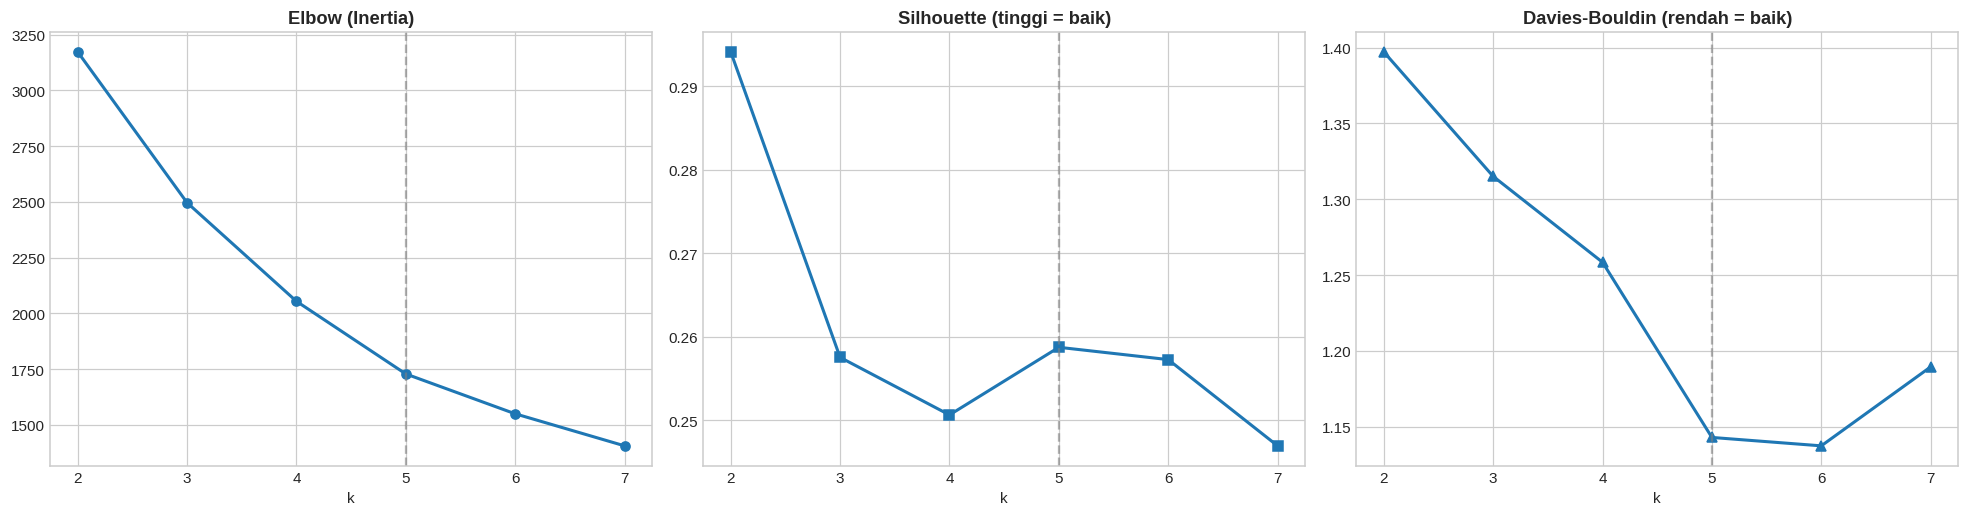

 k  Inertia  Silhouette    DBI
 2   3172.8      0.2941 1.3972
 3   2496.5      0.2575 1.3151
 4   2054.4      0.2507 1.2585
 5   1728.5      0.2588 1.1430
 6   1549.9      0.2573 1.1375
 7   1406.1      0.2470 1.1895


In [67]:
k_values = list(range(2, 8))
inertias, sil, dbi = [], [], []
for k in k_values:
    m = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    inertias.append(m.inertia_)
    sil.append(silhouette_score(Xs, m.labels_))
    dbi.append(davies_bouldin_score(Xs, m.labels_))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, y, t, mk in zip(axes, [inertias, sil, dbi],
        ['Elbow (Inertia)', 'Silhouette (tinggi = baik)', 'Davies-Bouldin (rendah = baik)'], ['o','s','^']):
    ax.plot(k_values, y, marker=mk, linewidth=2); ax.set_title(t, fontweight='bold')
    ax.set_xlabel('k'); ax.axvline(5, color='gray', ls='--', alpha=.6)
plt.tight_layout(); plt.show()

eval_df = pd.DataFrame({'k': k_values, 'Inertia': np.round(inertias, 1),
                        'Silhouette': np.round(sil, 4), 'DBI': np.round(dbi, 4)})
print(eval_df.to_string(index=False))

### Pemilihan k = 5
- **k = 2** memiliki Silhouette tertinggi (0.2941); **k = 6** memiliki DBI terendah (1.1375).
- **k = 5** bukan pemenang absolut salah satu metrik. Ia dipilih sebagai **kompromi** antara kualitas pemisahan (DBI 1.1430 hampir setara k = 6), stabilitas, dan interpretabilitas profil perilaku (k = 2 terlalu kasar untuk segmentasi).
- Seluruh Silhouette berada di kisaran ~0.25-0.29, yaitu struktur klaster **lemah-sedang**; klaster dibaca sebagai segmen deskriptif, bukan kategori tegas.
- **Catatan k = 4:** pada baseline seluruh pemain (sebelum filter), Silhouette puncak di k = 4 (0.3189). k = 4 ditinggalkan karena klaster baseline dibedakan oleh jumlah observasi (dua klaster berisi 2.728 pemain, 66%, bermedian 2 taruhan, satu `win_rate` 1.00 dan satu 0.00), bukan oleh perilaku. Setelah filter ≥10 taruhan, k = 4 lebih buruk daripada k = 5 pada kedua metrik (Silhouette 0.2507 vs 0.2588; DBI 1.2585 vs 1.1430).

In [68]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(Xs)
d['Cluster'] = km5.labels_
print(d['Cluster'].value_counts().sort_index())

Cluster
0    297
1    244
2    109
3    235
4    226
Name: count, dtype: int64


## 9. Uji Stabilitas
ARI antar-pasangan dari 5 random seed, serta ARI subsample 80% (20 kali) terhadap model penuh. ARI mengukur kestabilan partisi, **bukan** validitas substantif.

In [69]:
import itertools
from sklearn.metrics import adjusted_rand_score
seeds = [0, 7, 21, 42, 99]
labs = [KMeans(5, random_state=s, n_init=10).fit(Xs).labels_ for s in seeds]
aris = [adjusted_rand_score(a, b) for a, b in itertools.combinations(labs, 2)]
print(f'ARI antar seed  : min={min(aris):.4f}  mean={np.mean(aris):.4f}')

rng = np.random.default_rng(0)
sub = []
for i in range(20):
    idx = rng.choice(len(Xs), int(0.8 * len(Xs)), replace=False)
    m = KMeans(5, random_state=i, n_init=10).fit(Xs[idx])
    sub.append(adjusted_rand_score(km5.predict(Xs[idx]), m.labels_))
print(f'ARI subsample 80%: min={min(sub):.3f}  mean={np.mean(sub):.3f}')

ARI antar seed  : min=0.9912  mean=0.9965
ARI subsample 80%: min=0.703  mean=0.939


## 10. Profiling Klaster (Perilaku → Klaster, Profit = Outcome Pembanding)
Karena profit sangat *skewed* oleh pencilan, ringkasan utama memakai **median** dan **% pemain rugi**; rata-rata hanya informasi tambahan.

In [77]:
g = d.groupby('Cluster')
profile = g[['total_bets', 'avg_bet', 'win_rate', 'avg_cashout', 'total_profit']].median().round(2)
profile.insert(0, 'n', g.size())
profile['pct_rugi'] = g['total_profit'].apply(lambda s: (s < 0).mean()).round(2)
profile['pct_tak_pernah_menang'] = g['win_rate'].apply(lambda s: (s == 0).mean()).round(2)
profile['mean_total_profit'] = g['total_profit'].mean().round(1)

# Label deskriptif netral, diturunkan dari median (bukan hard-coded per indeks)
labels = {}
rest = list(profile.index)
labels[profile['avg_bet'].idxmax()] = 'Taruhan Nominal Tinggi'; rest.remove(profile['avg_bet'].idxmax())
hi = profile.loc[rest, 'avg_cashout'].idxmax(); labels[hi] = 'Target Cashout Tinggi'; rest.remove(hi)
fr = profile.loc[rest, 'total_bets'].idxmax(); labels[fr] = 'Frekuensi Tinggi, Target Rendah'; rest.remove(fr)
lo, mid = sorted(rest, key=lambda c: profile.loc[c, 'avg_cashout'])
labels[lo] = 'Target Rendah, Win Rate Tinggi'; labels[mid] = 'Target Menengah'
profile['label'] = profile.index.map(labels)
d['Label'] = d['Cluster'].map(labels)
profile.sort_values('avg_cashout')

,n,total_bets,avg_bet,win_rate,avg_cashout,total_profit,pct_rugi,pct_tak_pernah_menang,mean_total_profit,label
Cluster,,,,,,,,,,
0,297,17.0,43.18,0.80,1.19,12.67,0.40,0.00,93.4,"Target Rendah, Win Rate Tinggi"
3,235,69.0,39.16,0.68,1.37,-10.18,0.51,0.00,1198.9,"Frekuensi Tinggi, Target Rendah"
4,226,20.0,2225.25,0.60,1.49,1673.33,0.43,0.00,29498.8,Taruhan Nominal Tinggi
1,244,16.0,83.71,0.33,2.30,-65.53,0.61,0.05,-1089.3,Target Menengah
2,109,36.0,106.46,0.14,9.05,-172.62,0.61,0.00,-8532.9,Target Cashout Tinggi


In [71]:
from scipy.stats import spearmanr
r_cw = spearmanr(d.avg_cashout, d.win_rate)[0]
r_cp = spearmanr(d.avg_cashout, d.total_profit)[0]
r_wp = spearmanr(d.win_rate, d.total_profit)[0]
print(f'Spearman avg_cashout vs win_rate    : {r_cw:+.2f}')
print(f'Spearman avg_cashout vs total_profit: {r_cp:+.2f}')
print(f'Spearman win_rate    vs total_profit: {r_wp:+.2f}')

Spearman avg_cashout vs win_rate    : -0.79
Spearman avg_cashout vs total_profit: -0.04
Spearman win_rate    vs total_profit: +0.25


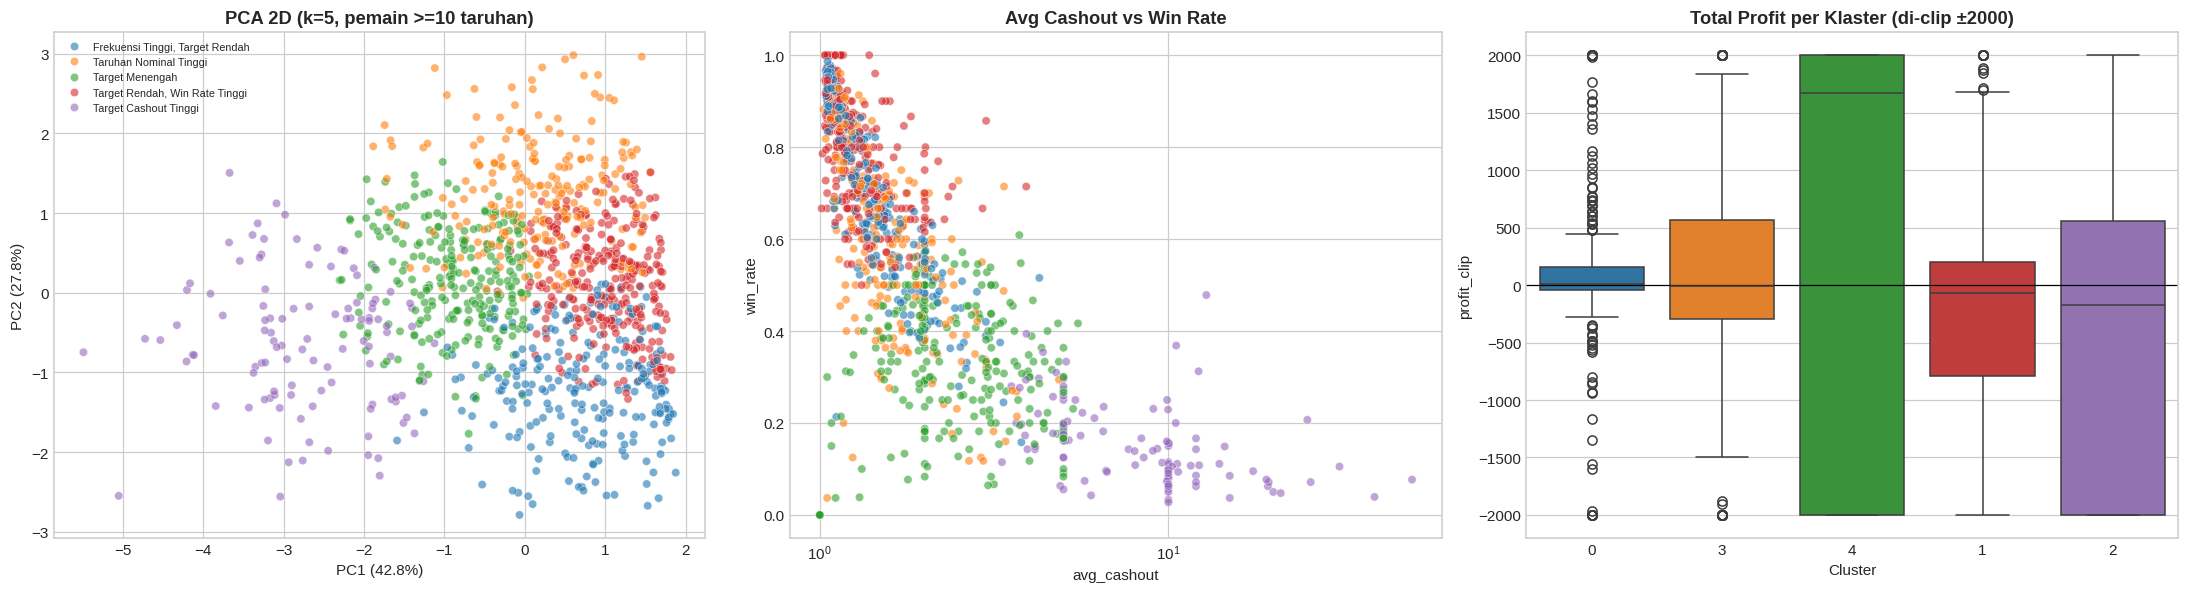

In [72]:
pal = sns.color_palette('tab10', 5)
pca = PCA(n_components=2, random_state=42)
co = pca.fit_transform(Xs)
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.scatterplot(x=co[:, 0], y=co[:, 1], hue=d['Label'], palette=pal, alpha=.6, s=30, ax=axes[0])
axes[0].set_title('PCA 2D (k=5, pemain >=10 taruhan)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=7)

sns.scatterplot(data=d, x='avg_cashout', y='win_rate', hue='Label', palette=pal, alpha=.6, s=30, ax=axes[1], legend=False)
axes[1].set_xscale('log'); axes[1].set_title('Avg Cashout vs Win Rate', fontweight='bold')

order = profile.sort_values('avg_cashout').index
dd = d.assign(profit_clip=d.total_profit.clip(-2000, 2000))
sns.boxplot(data=dd, x='Cluster', y='profit_clip', order=order, palette=pal, ax=axes[2])
axes[2].axhline(0, color='k', lw=.8); axes[2].set_title('Total Profit per Klaster (di-clip ±2000)', fontweight='bold')
plt.tight_layout(); plt.show()

In [89]:
cl = 'Cluster' if 'Cluster' in d.columns else 'cluster'

# ROI per klaster
m = df.merge(d[['Username', cl]], on='Username')
roi = m.groupby(cl).apply(lambda x: pd.Series({
    'roi': x['actual_profit'].sum() / x['Bet'].sum(),
    'total_bet': x['Bet'].sum()}))
roi['porsi_volume'] = (roi['total_bet'] / roi['total_bet'].sum()).round(3)
print(roi.round(4))

            roi   total_bet  porsi_volume
cluster                                  
0        0.0443    625938.0         0.006
1       -0.2464   1078868.0         0.010
2       -0.2325   3999766.0         0.038
3        0.0438   6437353.0         0.060
4        0.0707  94346396.0         0.886


### ROI per Klaster
ROI = total profit / total taruhan per klaster. Klaster *Target Menengah* dan *Target Cashout Tinggi* mencatat ROI -24,6% dan -23,3%, sedangkan tiga klaster lain +4,4%, +4,4%, dan +7,1%. Klaster *Taruhan Nominal Tinggi* memegang 88,6% dari total volume taruhan, sehingga ROI gabungan sampel (sekitar +5,4%) didominasi segelintir pemain bernominal besar. Angka ini tidak membuktikan bahwa platform merugikan atau menguntungkan tipe pemain tertentu: dataset hanya mencakup 50.000 transaksi, `Profit` mungkin sudah memuat `Bonus`, dan klaster bertarget tinggi secara desain memiliki varians hasil lebih besar. ROI dibaca sebagai indikasi, bukan angka final.

## 11. Uji Sensitivitas Threshold (min_bets = 5, 10, 20)
Threshold dipilih setelah audit pada baseline menunjukkan bahwa klaster dibedakan oleh jumlah observasi, bukan perilaku. Uji sensitivitas memastikan temuan tidak hanya muncul pada angka 10.

In [73]:
rows, profs = [], {}
for mb in [5, 10, 20]:
    dm = user_df[user_df.total_bets >= mb].copy()
    Xm, _ = prepare(dm)
    mm = KMeans(5, random_state=42, n_init=10).fit(Xm)
    ls = [KMeans(5, random_state=s, n_init=10).fit(Xm).labels_ for s in seeds]
    ar = [adjusted_rand_score(a, b) for a, b in itertools.combinations(ls, 2)]
    dm['c'] = mm.labels_
    gm = dm.groupby('c')
    p = gm[['avg_cashout', 'win_rate', 'total_profit']].median().round(2)
    p['n'] = gm.size(); p['pct_rugi'] = gm['total_profit'].apply(lambda s: (s < 0).mean()).round(2)
    profs[mb] = p.sort_values('avg_cashout')
    rows.append({'min_bets': mb, 'n_pemain': len(dm), 'cakupan': f'{len(dm)/len(user_df):.1%}',
                 'silhouette': round(silhouette_score(Xm, mm.labels_), 4),
                 'DBI': round(davies_bouldin_score(Xm, mm.labels_), 4), 'ARI_min_5seed': round(min(ar), 4)})
print(pd.DataFrame(rows).to_string(index=False))
for mb, p in profs.items():
    print(f'\n--- min_bets={mb} (urut avg_cashout naik) ---'); print(p)

 min_bets  n_pemain cakupan  silhouette    DBI  ARI_min_5seed
        5      1764   42.5%      0.2573 1.1511         0.9577
       10      1111   26.8%      0.2588 1.1430         0.9912
       20       643   15.5%      0.2745 1.1413         0.8921

--- min_bets=5 (urut avg_cashout naik) ---
   avg_cashout  win_rate  total_profit    n  pct_rugi
c                                                    
3         1.22      0.82         16.24  457      0.34
4         1.35      0.70         11.07  358      0.47
2         1.47      0.60        343.18  371      0.48
0         2.00      0.33        -75.52  402      0.68
1         5.55      0.17        -51.08  176      0.56

--- min_bets=10 (urut avg_cashout naik) ---
   avg_cashout  win_rate  total_profit    n  pct_rugi
c                                                    
0         1.19      0.80         12.67  297      0.40
3         1.37      0.68        -10.18  235      0.51
4         1.49      0.60       1673.33  226      0.43
1         2.30 

## 12. Penyimpanan Artefak Final

In [74]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(km5, 'kmeans.pkl')
print('Tersimpan: scaler.pkl, kmeans.pkl (pipeline final: min_bets=10, k=5, fitur perilaku)')

Tersimpan: scaler.pkl, kmeans.pkl (pipeline final: min_bets=10, k=5, fitur perilaku)


## 13. Kesimpulan & Batasan

### Hasil utama
1. **Cakupan:** analisis akhir berlaku untuk **1.111 dari 4.149 pemain (26,8%)**, yaitu pemain dengan minimal 10 taruhan. Pemain dengan <10 taruhan dikeluarkan karena observasinya terlalu sedikit untuk profiling perilaku yang stabil; hasil **tidak** digeneralisasi ke seluruh pemain.
2. **Jumlah klaster:** k = 5 dipilih sebagai **kompromi** antara pemisahan klaster, stabilitas, dan interpretabilitas. k = 2 unggul pada Silhouette dan k = 6 unggul pada DBI, sehingga k = 5 tidak diklaim "optimal".
3. **Pola utama (asosiasi, bukan kausalitas):** pada klaster *Target Rendah → Menengah → Tinggi*, median `avg_cashout` naik (1.19 → 2.30 → 9.05) sementara `win_rate` turun (0.80 → 0.33 → 0.14). Median `total_profit` negatif pada klaster bertarget ≥ 2x (-65.53 dan -172.62), dengan 61% pemain rugi. `win_rate` turun konsisten pada min_bets = 5, 10, dan 20, dan median profit negatif pada klaster bertarget ≥ 2x di ketiga threshold, tetapi besarnya tidak monoton (pada min_bets = 5 klaster 5.55x berprofit median -51.08, lebih baik daripada klaster 2.00x yang -75.52). Pola terbentuk **tanpa** profit sebagai fitur clustering. Pada level pemain korelasi `avg_cashout` dengan `total_profit` mendekati nol (lihat Batasan).
4. **Taruhan nominal tinggi ≠ pasti rugi:** klaster dengan `avg_bet` median ≈ 2.225 bits memiliki median profit positif (+1.673) dan 43% pemain rugi.
5. **Stabilitas:** ARI antar 5 seed ≥ 0.99 pada min_bets = 10; ARI subsample 80% rata-rata ≈ 0.94. Ini menunjukkan partisi stabil secara komputasi, **bukan** bukti bahwa segmentasi benar secara domain.

6. **Eksposur (ROI):** ROI klaster bertarget menengah dan tinggi sekitar -24,6% dan -23,3%, sedangkan tiga klaster lain +4,4%, +4,4%, dan +7,1%. Klaster *Taruhan Nominal Tinggi* memegang 88,6% volume taruhan sehingga ROI gabungan sampel (sekitar +5%) didominasi segelintir pemain bernominal besar. Data ini **tidak** mendukung klaim bahwa pemain pasti rugi.

### Batasan yang harus dinyatakan
- Silhouette 0.25-0.29 → struktur klaster lemah-sedang; klaster adalah segmen deskriptif, bukan arketipe tegas.
- Korelasi `avg_cashout` dengan `win_rate` sebagian bersifat **mekanis** (target multiplier lebih tinggi secara desain game lebih jarang tercapai). Pada level pemain, korelasi `avg_cashout` dengan `total_profit` mendekati nol (lihat Bagian 10), sehingga "target tinggi → profit buruk" hanya terlihat pada ringkasan median klaster dan tidak boleh dibaca sebagai hubungan kuat atau kausal.
- **Survivorship bias:** filter minimal 10 taruhan hanya menyisakan pemain yang bertahan bermain. Pemain yang cepat kehilangan modal cenderung tidak lolos filter, sehingga kerugian pada sampel ini kemungkinan terlihat lebih kecil daripada kenyataan.
- Hasil klaster **tidak** membuktikan bahwa platform menarget tipe pemain tertentu. Perbedaan antar-klaster mencerminkan pilihan target dan varians hasil, bukan perlakuan berbeda dari sistem.
- ROI dan profit didominasi segelintir pemain bernominal besar dan `Profit` mungkin sudah memuat `Bonus`; dibaca sebagai indikasi, bukan angka final.
- Rata-rata profit sangat dipengaruhi pencilan; ringkasan utama memakai median dan % pemain rugi.
- `avg_cashout = 1.0` untuk pemain yang belum pernah menang adalah **nilai imputasi**, bukan cashout teramati. Pada k = 5 pemain tanpa kemenangan hanya sekitar 5% pada satu klaster.
- Profit dihitung dari dataset tunggal (50.000 transaksi) dan tidak mencerminkan seluruh riwayat pemain.

### Batasan Pengerjaan
Sesuai ketentuan penugasan CPMK2, pengerjaan dihentikan pada tahap **Model Evaluation & Interpretation**, tanpa deployment aplikasi atau antarmuka pengguna.

### Batasan Pengerjaan
Sesuai ketentuan penugasan CPMK2, pengerjaan dihentikan pada tahap **Model Evaluation & Interpretation**, UTS tanpa deployment model dengan interface.